In [1]:
!pip install transformers pandas torch accelerate bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 MB 17.8 MB/s eta 0:00:00


In [3]:
from google.colab import files
uploaded = files.upload()

Saving final_dataset.csv to final_dataset.csv


In [2]:
from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline, BitsAndBytesConfig
import torch

MODEL_NAME = "Qwen/Qwen2.5-7B-Instruct"

quantization_config = BitsAndBytesConfig(
    load_in_8bit=True,
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=quantization_config,
    device_map="auto",
    torch_dtype=torch.float16,
)

generator = pipeline("text-generation", model=model, tokenizer=tokenizer)
print("Model loaded successfully")

config.json:   0%|          | 0.00/663 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/243 [00:00<?, ?B/s]

Model loaded successfully


In [4]:
import json

_decoder = json.JSONDecoder()

def extract_first_json(text: str):
    text = text.strip()
    start = text.find("{")
    if start == -1:
        return None
    try:
        obj, _ = _decoder.raw_decode(text[start:])
        return obj
    except json.JSONDecodeError:
        return None


def generate_sentiment(transcript, description, expression, prompt_template):
    prompt = prompt_template.format(
        transcript=transcript,
        description=description,
        expression=expression,
    )




    result = generator(prompt, max_new_tokens=200, do_sample=False, return_full_text=False)
    raw_output = result[0]["generated_text"].strip()

    parsed = extract_first_json(raw_output)

    if parsed is None:
        return {"raw_output": raw_output, "predicted_sentiment": "unknown"}

    model_stated_class = parsed.get("class", "unknown")
    if model_stated_class not in ("positive", "negative", "neutral"):
        model_stated_class = "unknown"

    return {"raw_output": raw_output, "predicted_sentiment": model_stated_class}

In [5]:
from google.colab import files
uploaded = files.upload()

Saving prompt_fewshot.txt to prompt_fewshot.txt


In [6]:
import pandas as pd
from pathlib import Path



prompt_template = Path("prompt_fewshot.txt").read_text(encoding="utf-8")
print(prompt_template)
df = pd.read_csv("final_dataset.csv")
df = df[df["transcript"].notna()].reset_index(drop=True)
print(f"Loaded {len(df)} rows")

CLASS_TO_SENTIMENT = {"pos": "positive", "neg": "negative", "neutral": "neutral"}


predicted_sentiments = []
raw_outputs = []

for idx, row in df.iterrows():

    result = generate_sentiment(
        row["transcript"], row["description"], row["facial_expression"], prompt_template
    )

    predicted_sentiments.append(result["predicted_sentiment"])
    raw_outputs.append(result["raw_output"])
    print(f"[{idx}] Predicted: {result['predicted_sentiment']}")

df["true_sentiment"] = df["class"].map(CLASS_TO_SENTIMENT)
df["predicted_sentiment"] = predicted_sentiments
df["raw_model_output"] = raw_outputs
df["is_correct"] = df["true_sentiment"] == df["predicted_sentiment"]

accuracy = df["is_correct"].mean()
print(f"\nAccuracy: {accuracy:.2%}")
print("Confusion Matrix (true vs predicted):")
confusion = pd.crosstab(df["true_sentiment"], df["predicted_sentiment"], margins=True)
print(confusion)
print(f" unknown: {(df['predicted_sentiment'] == 'unknown').sum()}")



[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


You are an expert sentiment classifier for CeraVe skincare product reviews.
Classify into exactly ONE sentiment: positive, negative, or neutral.
Rules:
Neutral = descriptive content (routines, ingredients, steps) with no clear opinion.
Positive = explicit statement of satisfaction or improvement.
Negative = explicit complaint or dissatisfaction.
If unsure between negative and neutral, choose neutral.
Example 1:
Transcript: "I've been using this moisturizer for a month and my skin has
never looked better."
Description: "CeraVe moisturizer review"
Facial Expression: "happy"
Output:
{{
  "class": "positive",
  "confidence": 97
}}
Example 2:
Transcript: "This cleanser caused redness and breakouts. I won't buy it again."
Description: "CeraVe cleanser review"
Facial Expression: "angry"
Output:
{{
  "class": "negative",
  "confidence": 98
}}
Example 3:
Transcript: "Today I'm showing my skincare routine using CeraVe cleanser
and moisturizer."
Description: "Morning skincare routine"
Facial Expr

[transformers] Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer Qwen2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.
[transformers] Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[0] Predicted: positive


[transformers] Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

[56] Predicted: negative


[transformers] Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[57] Predicted: negative


[transformers] Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[58] Predicted: negative
[59] Predicted: neutral

Accuracy: 98.33%
Confusion Matrix (true vs predicted):
predicted_sentiment  negative  neutral  positive  All
true_sentiment                                       
negative                   23        0         0   23
neutral                     0       14         0   14
positive                    0        1        22   23
All                        23       15        22   60
 unknown: 0


In [7]:
!pip install scikit-learn

In [8]:
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd

eval_df = df[df["predicted_sentiment"] != "unknown"].copy()

print("=" * 60)
print("Classification Report:")
print("=" * 60)
report_dict = classification_report(
    eval_df["true_sentiment"],
    eval_df["predicted_sentiment"],
    labels=["positive", "negative", "neutral"],
    zero_division=0,
    output_dict=True
)


report_df = pd.DataFrame(report_dict).transpose()
print(report_df)

report_df.to_csv("classification_report.csv", index=False)
from google.colab import files
files.download("classification_report.csv")


print("=" * 60)
print("Confusion Matrix:")
print("=" * 60)
cm = confusion_matrix(
    eval_df["true_sentiment"],
    eval_df["predicted_sentiment"],
    labels=["positive", "negative", "neutral"]
)
cm_df = pd.DataFrame(
    cm,
    index=[f"true_{l}" for l in ["positive", "negative", "neutral"]],
    columns=[f"pred_{l}" for l in ["positive", "negative", "neutral"]]
)
print(cm_df)
cm_df.to_csv("confusion_matrix.csv", index=False)
from google.colab import files
files.download("confusion_matrix.csv")


Classification Report:
              precision    recall  f1-score    support
positive       1.000000  0.956522  0.977778  23.000000
negative       1.000000  1.000000  1.000000  23.000000
neutral        0.933333  1.000000  0.965517  14.000000
accuracy       0.983333  0.983333  0.983333   0.983333
macro avg      0.977778  0.985507  0.981098  60.000000
weighted avg   0.984444  0.983333  0.983436  60.000000


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Confusion Matrix:
               pred_positive  pred_negative  pred_neutral
true_positive             22              0             1
true_negative              0             23             0
true_neutral               0              0            14


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

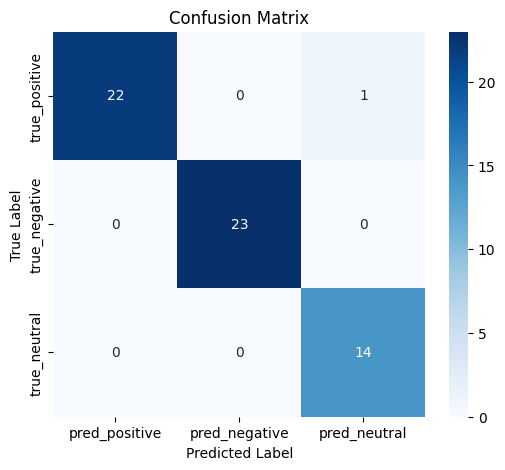

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [9]:
from google.colab import files
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.savefig("confusion_matrix.png", bbox_inches="tight", dpi=300)
plt.show()
files.download("confusion_matrix.png")

In [10]:
df.to_csv("predictions_df.csv", index=False)

from google.colab import files
files.download("predictions_df.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>